## Initialize and Authenticate Earth Engine
To get started with Google Earth Engine (GEE), you need to initialize and authenticate the Earth Engine API. Follow these steps.


First, import the Earth Engine API by importing the ee module into your Python environment. This module allows you to interact with the Earth Engine platform.


In [1]:
# Import the API
import ee

Next, initialize the Earth Engine API.

In [2]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='ee-escuelavirtualgis') ## Change to your EE project

## Install and import libraries
Next, import the essential libraries needed to process and analyze the datasets.

In [3]:
# Import the necessary libraries
import geemap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Prepare predictor variables


In [4]:
# Load the boundary
boundary = ee.FeatureCollection('projects/ee-escuelavirtualgis/assets/Berlin')

### Create composite
 DEM + Derivados

In [5]:
# ========================
# 1) DEM + Derivados base
# ========================
dem30  = ee.Image('USGS/SRTMGL1_003').select('elevation').clip(boundary)     # 30 m
terrain = ee.Terrain.products(dem30)
slope   = terrain.select('slope')   # grados
aspect  = terrain.select('aspect')  # grados

# Curvatura (aprox.) vía Laplaciano
curvature = dem30.convolve(ee.Kernel.laplacian8()).rename('curvature').clip(boundary)

# =========================================
# 2) TWI desde MERIT Hydro + SRTM (a 30 m)
#    TWI = ln( SCA / tan(slope) )
# =========================================
upa_km2    = ee.Image('MERIT/Hydro/v1_0_1').select('upa').clip(boundary)  # ~90 m (km²)
cell_merit = upa_km2.projection().nominalScale()                          # tamaño celda (m)

# SCA ≈ upa(km²) -> m² y por unidad de ancho de celda
sca = upa_km2.multiply(1e6).divide(cell_merit)                            # m²/m

# tan(slope) (slope en radianes); evita 0 para no generar inf
pi = ee.Number(3.141592653589793)
tanSlope = slope.multiply(pi.divide(180)).tan()
tanSlope = tanSlope.where(tanSlope.lte(0), 1e-6)

twi = sca.divide(tanSlope).log().rename('TWI').clip(boundary)
twi_30m = twi.reproject(crs=dem30.projection(), scale=30)

# ================================
# 3) HAND (MERIT Hydro) a 30 m
# ================================
hand = ee.Image('MERIT/Hydro/v1_0_1').select('hnd').clip(boundary)
hand_30m = hand.reproject(crs=dem30.projection(), scale=30).rename('HAND')

# ===========================================
# 4) Distancia euclidiana a VÍAS (GRIP4 EUR)
# ===========================================
roads_fc = ee.FeatureCollection('projects/sat-io/open-datasets/GRIP4/Europe') \
            .filterBounds(boundary)

# Raster binario (1 en vías)
roads_bin = ee.Image(0).byte().paint(roads_fc, 1).selfMask().clip(boundary)

# Distancia euclidiana (m) con radio de cálculo (ajústalo si quieres)
radius_m = 5000
dist_to_roads = roads_bin.distance(
    kernel=ee.Kernel.euclidean(radius_m, 'meters'),
    skipMasked=False
).rename('dist_roads_m').clip(boundary)

# Initialize map1 here
map1 = geemap.Map()

# DEM con percentiles para estirar contraste
dem_min = dem30.reduceRegion(ee.Reducer.percentile([2]),  boundary, 90).get('elevation')
dem_max = dem30.reduceRegion(ee.Reducer.percentile([98]), boundary, 90).get('elevation')

map1.addLayer(dem30,     {'min': dem_min, 'max': dem_max,
                          'palette': ['081d58','225ea8','41b6c4','a1dab4','ffffcc']}, 'DEM 30m')

map1.addLayer(slope,     {'min':0,  'max':30}, 'Pendiente (°)')
map1.addLayer(aspect,    {'min':0,  'max':360,
                          'palette':['00224d','2a9df4','a1d2ff','ffffcc','ffc857','f28f3b','e15554']}, 'Aspecto (°)')
map1.addLayer(curvature, {'min':-5, 'max':5,
                          'palette':['542788','998ec3','f7f7f7','f1a340','b35806']}, 'Curvatura')
map1.addLayer(twi_30m,   {'min':3,  'max':20,
                          'palette':['f7fbff','c6dbef','6baed6','2171b5','08306b']}, 'TWI 30m')
map1.addLayer(hand_30m,  {'min':0,  'max':30,
                          'palette':['edf8fb','bfd3e6','9ebcda','8c96c6','8856a7','810f7c']}, 'HAND 30m')

# Distancia a vías
vis_dist = {'min': 0, 'max': radius_m,
            'palette': ['001d4a','0067a5','4fb3ff','bfe6ff','ffffff']}

map1.addLayer(dist_to_roads, vis_dist, 'Distancia a vías (m)')

# =====================
# 5) Visual al Mapa
# =====================
map1.centerObject(boundary, 11)
map1

Map(center=[52.50307568471608, 13.398289700739916], controls=(WidgetControl(options=['position', 'transparent_…

In [6]:
# 1) Land cover ESA WorldCover (10 m)
#    Remapeamos a binario: 1 = agua (80 Open Water; opcional 90 Wetlands, 95 Mangroves), 0 = demás
lc10 = ee.ImageCollection("ESA/WorldCover/v100").first().select('Map')

water_bin_10m = lc10.remap(
    [10, 20, 30, 40, 50, 60, 70, 80, 90, 95],   # clases ESA
    [0,   0,  0,  0,  0,  0,  0,  1,  1,  1]    # 1 = agua (80/90/95); ajusta si quieres solo 80
).rename('water').selfMask().clip(boundary)

water_30m = water_bin_10m

# Si quieres forzar preview a 30 m en el mapa, descomenta la línea siguiente:
# water_30m = water_bin_10m.resample('nearest').reproject(crs=dem30.projection(), scale=30)

# 3) Distancia euclidiana (m) hasta el píxel de agua más cercano
#    Ajusta 'radius_m' según tu alcance de interés
radius_m = 5000

dist_OW = water_30m.distance(
    kernel=ee.Kernel.euclidean(radius_m, 'meters'),
    skipMasked=False
).rename('dist_to_water_m').clip(boundary)

# 4) Mostrar en el mapa
map1 = geemap.Map()
map1.centerObject(boundary, 11)
map1.addLayer(dist_OW, {'min': 0, 'max': radius_m,
                        'palette': ['22ff20','1a35ff','ffa925','ff0a36','2fe1ff','fd4bff']},
              'Distancia a agua (m) - 30 m')

map1.addLayerControl()
map1

Map(center=[52.50307568471605, 13.398289700740003], controls=(WidgetControl(options=['position', 'transparent_…

In [8]:
# ================================
# Landsat 8 + 9 C2 L2 (30 m) + NDVI
# ================================

start_date = '2021-01-01'
end_date   = '2022-12-31'

# --- Máscara L2 usando QA_PIXEL (nube, sombra, cirrus, nieve) ---
def mask_l89_l2(img):
    qa = img.select('QA_PIXEL')
    cloud_shadow = qa.bitwiseAnd(1 << 3).eq(0)
    snow         = qa.bitwiseAnd(1 << 4).eq(0)
    cloud        = qa.bitwiseAnd(1 << 5).eq(0)
    cirrus       = qa.bitwiseAnd(1 << 7).eq(0)
    m = cloud_shadow.And(snow).And(cloud).And(cirrus)
    # Escalado reflectancia y temperatura (C2 L2)
    optical = img.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = img.select('ST_B.*').multiply(0.00341802).add(149.0)  # Kelvin
    scaled  = (img.addBands(optical, None, True)
                 .addBands(thermal, None, True))
    return scaled.updateMask(m)

# --- Colecciones L8/L9 C2 T1 L2 ---
l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(boundary)
        .filterDate(start_date, end_date))
l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(boundary)
        .filterDate(start_date, end_date))

l89 = l8.merge(l9).map(mask_l89_l2)

# --- Seleccionar bandas ópticas para RGB/NDVI ---
opt = l89.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6'])  # B2 Blue, B3 Green, B4 Red, B5 NIR

# --- Compuesto mediano y recorte ---
l89_median = opt.median().clip(boundary)

# --- NDVI (B5 - B4) / (B5 + B4) ---
ndvi = l89_median.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI')


# --- Mapa ---
map1 = geemap.Map()
map1.centerObject(boundary, 11)

# RGB natural 4-3-2
vis_rgb = {'bands': ['SR_B4','SR_B3','SR_B2'], 'min': 0, 'max': 0.3}
map1.addLayer(l89_median, vis_rgb, 'Landsat 8/9 C2 L2 (RGB 4-3-2)')

# NDVI
map1.addLayer(ndvi, {'min': -0.2, 'max': 0.9, 'palette': ['#8b0000','#ffffff','#006400']}, 'NDVI (L8+L9)')

map1.addLayerControl()
map1


Map(center=[52.50307568471605, 13.398289700740003], controls=(WidgetControl(options=['position', 'transparent_…

### Compute spectral indices
Next, calculate NDVI, SAVI, and RESI from the Sentinel-2 composite. T

### Merge all predictor variables


In [9]:
# ===============================
# ===============================
target_crs_string = 'EPSG:32633'
target_scale = 30  # metros

# Reproyectar todas las capas al mismo CRS (UTM 18N) y escala 30 m
dem_utm      = dem30.reproject(crs=target_crs_string, scale=target_scale)
slope_utm    = slope.reproject(crs=target_crs_string, scale=target_scale)
aspect_utm   = aspect.reproject(crs=target_crs_string, scale=target_scale)
curv_utm     = curvature.reproject(crs=target_crs_string, scale=target_scale)
twi_utm      = twi_30m.reproject(crs=target_crs_string, scale=target_scale)
hand_utm     = hand_30m.reproject(crs=target_crs_string, scale=target_scale)
dist_utm     = dist_to_roads.reproject(crs=target_crs_string, scale=target_scale)
dist_OW     = dist_OW.reproject(crs=target_crs_string, scale=target_scale)

landsat_utm  = l89_median.reproject(crs=target_crs_string, scale=target_scale)
ndvi_utm     = ndvi.reproject(crs=target_crs_string, scale=target_scale)


In [10]:
# ===========================
# Crear imagen multibanda
# ===========================
def cast32(img):
    return img.toFloat()

merged_utm = (cast32(landsat_utm)
              .addBands(cast32(ndvi_utm).rename('NDVI'))
              .addBands(cast32(dem_utm).rename('DEM'))
              .addBands(cast32(slope_utm).rename('Slope'))
              .addBands(cast32(aspect_utm).rename('Aspect'))
              .addBands(cast32(curv_utm).rename('Curvature'))
              .addBands(cast32(twi_utm).rename('TWI'))
              .addBands(cast32(hand_utm).rename('HAND'))
              .addBands(cast32(dist_utm).rename('Dist_Roads'))
              .addBands(cast32(dist_OW).rename('dist_OW'))

             )

print(merged_utm.bandNames().getInfo())


['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'NDVI', 'DEM', 'Slope', 'Aspect', 'Curvature', 'TWI', 'HAND', 'Dist_Roads', 'dist_OW']


In [11]:
task_stack = ee.batch.Export.image.toDrive(
    image        = merged_utm,
    description  = 'Merged_Stack_30m_32633',
    fileNamePrefix = 'Merged_Stack_30m_32633',
    region       = boundary.geometry(),   # tu área de estudio
    crs          = 'EPSG:32633',          # UTM 33N
    scale        = 30,
    maxPixels    = 1e13,
    fileFormat   = 'GeoTIFF'
)
task_stack.start()
print("🌍 Exportando stack en UTM 33N (Merged_Stack_30m_UTM33N.tif)")


🌍 Exportando stack en UTM 33N (Merged_Stack_30m_UTM33N.tif)


## Sampling training data in Google Earth Engine
We will select specific bands from the 'clippedmergedCollection' and then sample the values (spectral reflectance values) at the locations of the 'trainingData' points.


In [12]:
import geopandas as gpd

points = gpd.read_file("Points.shp")

# Asignar CRS UTM 33N (NO transformar, solo declarar el CRS que realmente tienen)
points_utm = points.set_crs(epsg=32633, inplace=False)
print("CRS asignado:", points_utm.crs)
points_wgs84 = points_utm.to_crs(epsg=4326)
print("CRS convertido a WGS84:", points_wgs84.crs)


def gdf_to_ee_fc(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point(row.geometry.x, row.geometry.y)
        feat = ee.Feature(geom, row.drop(labels='geometry').to_dict())
        features.append(feat)
    return ee.FeatureCollection(features)

points_fc = gdf_to_ee_fc(points_wgs84)
print("✅ Puntos convertidos a FeatureCollection para GEE")



Map = geemap.Map()
Map.centerObject(points_fc, 12)
Map.addLayer(points_fc, {"color": "yellow"}, "Puntos de entrenamiento")
Map





CRS asignado: EPSG:32633
CRS convertido a WGS84: EPSG:4326
✅ Puntos convertidos a FeatureCollection para GEE


Map(center=[52.50220375512335, 13.379312593120252], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
print("Bounds:", points_wgs84.total_bounds)


Bounds: [13.26429735 52.45941971 13.61225478 52.57781511]


In [13]:

# Bandas predictoras que existen dentro de 'merged'
predictor_bands = [
    'SR_B2','SR_B3','SR_B4','SR_B5','SR_B6',  # Landsat óptico
    'NDVI',                                   # índice
    'DEM','Slope','Aspect','Curvature',       # topografía
    'TWI','HAND','Dist_Roads','dist_OW'                # hidrología / distancia
]

# Nombre de la columna de la etiqueta en tus puntos
label_col = 'Label'   # asegúrate que tu shapefile tiene esta columna




In [14]:
# Extraer valores de las bandas en cada punto de entrenamiento
training_data = merged_utm.select(predictor_bands).sampleRegions(
    collection  = points_fc,
    properties  = [label_col],  # se lleva la columna Label a la tabla final
    scale       = 30,
    geometries  = False,
    tileScale   = 4
)

print("✅ Número de muestras extraídas:", training_data.size().getInfo())


✅ Número de muestras extraídas: 84


In [15]:
# Exportar tabla como CSV
task_csv = ee.batch.Export.table.toDrive(
    collection   = training_data,
    description  = 'inundacion',
    fileNamePrefix = 'inundacion',
    fileFormat   = 'CSV'
)
task_csv.start()
print("📄 Exportando CSV de entrenamiento a Drive (inundacion.csv)")


📄 Exportando CSV de entrenamiento a Drive (inundacion.csv)


In [16]:
# Si hace falta:
# !pip install scikit-learn rasterio joblib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

# 1. Cargar CSV (ajusta la ruta según dónde lo tengas)
df = pd.read_csv("inundacion.csv")

# Opcional: quedarnos solo con las columnas que necesitamos
cols_needed = predictor_bands + [label_col]
df = df[cols_needed].dropna()

X = df[predictor_bands].values
y = df[label_col].values

print("Tamaño X:", X.shape, "Tamaño y:", y.shape)

# 2. Train / test split para evaluar un poco el modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Escalado + Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # útil si hay clases desbalanceadas
    solver="lbfgs"
)
logit.fit(X_train_scaled, y_train)

# 4. Métricas rápidas
y_pred      = logit.predict(X_test_scaled)
y_proba     = logit.predict_proba(X_test_scaled)[:,1]
auc         = roc_auc_score(y_test, y_proba)

print("AUC:", auc)
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

# 5. Guardar modelo y scaler para usarlos con el raster
joblib.dump(logit,  "logit_model.pkl")
joblib.dump(scaler, "logit_scaler.pkl")
print("✅ Modelo y scaler guardados.")


Tamaño X: (84, 14) Tamaño y: (84,)
AUC: 0.7455621301775148
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.75      0.69      0.72        13
           1       0.71      0.77      0.74        13

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26

Matriz de confusión:
 [[ 9  4]
 [ 3 10]]
✅ Modelo y scaler guardados.


In [17]:
!pip install rasterio

In [19]:
import rasterio
import numpy as np
import joblib

# Cargar modelo y scaler
logit  = joblib.load("logit_model.pkl")
scaler = joblib.load("logit_scaler.pkl")

# 1. Abrir el stack
stack_path = "/content/Merged_Stack_30m_UTM33N.tif"
bands_order = [
    'SR_B2','SR_B3','SR_B4','SR_B5','SR_B6',
    'NDVI','DEM','Slope','Aspect','Curvature',
    'TWI','HAND','Dist_Roads','dist_OW'
]

with rasterio.open(stack_path) as src:
    data = src.read()   # shape: (nbands, rows, cols)
    profile = src.profile
    nodata = src.nodata

print("Shape stack:", data.shape)  # (13, filas, columnas)

# 2. Convertir a matriz 2D: (n_pixels, n_bandas)
nbands, nrows, ncols = data.shape
flat = data.reshape(nbands, -1).T   # (n_pix, 13)

# 3. Máscara de NoData (si aplica)
if nodata is not None:
    mask_invalid = np.any(flat == nodata, axis=1)
else:
    # si exportaste con máscaras, puedes usar NaN:
    mask_invalid = np.any(~np.isfinite(flat), axis=1)

# 4. Aplicar scaler + modelo solo en píxeles válidos
X_valid = flat[~mask_invalid]
X_valid_scaled = scaler.transform(X_valid)
proba_valid = logit.predict_proba(X_valid_scaled)[:, 1]  # probabilidad de clase 1 (inundado)

# 5. Reconstruir la imagen de probabilidades
proba_full = np.full(flat.shape[0], np.nan, dtype="float32")
proba_full[~mask_invalid] = proba_valid

proba_img = proba_full.reshape(nrows, ncols)

# 6. Guardar raster de susceptibilidad
out_profile = profile.copy()
out_profile.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

out_path = "Flood_Susceptibility_Logit.tif"
with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(proba_img, 1)

print("✅ Mapa de susceptibilidad guardado en:", out_path)


Shape stack: (14, 1227, 1458)
✅ Mapa de susceptibilidad guardado en: Flood_Susceptibility_Logit.tif


✅ Raster recortado a Berlín: (1227, 1458)
Umbrales usados: 0.10707792639732361 0.32737383246421814 0.5819170475006104 0.8219636678695679
💾 Guardado raster clasificado recortado a Berlín: /content/Flood_Susceptibility_Classes5_Logit_Berlin.tif


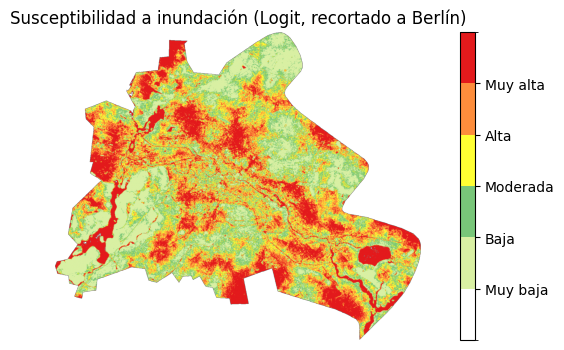

In [20]:
import rasterio
import numpy as np
import geopandas as gpd
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# -----------------------------
# 1. RASTER DE PROBABILIDAD
# -----------------------------
prob_path = "/content/Flood_Susceptibility_Logit.tif"

src = rasterio.open(prob_path)
prob_crs = src.crs

# -----------------------------
# 2. SHAPE DE BERLÍN (GADM)
# -----------------------------
shp_path = "/content/berlin_gadm.shp"  # tu capa

berlin = gpd.read_file(shp_path)
berlin = berlin.to_crs(prob_crs)       # lo llevamos al mismo CRS del raster

geoms = [feat["geometry"] for feat in berlin.__geo_interface__["features"]]

# -----------------------------
# 3. RECORTAR RASTER AL SHAPE
# -----------------------------
prob_clip, transform = mask(src, geoms, crop=True, filled=True, nodata=np.nan)
prob_clip = prob_clip[0]  # banda 1
profile = src.profile
src.close()

profile.update(
    height=prob_clip.shape[0],
    width=prob_clip.shape[1],
    transform=transform
)

print("✅ Raster recortado a Berlín:", prob_clip.shape)

# -----------------------------
# 4. CLASIFICAR EN 5 CLASES
#    Muy baja, baja, moderada, alta, muy alta
#    (usando cuantiles para que se vea mejor)
# -----------------------------
mask_valid = np.isfinite(prob_clip)
vals = prob_clip[mask_valid]

q20, q40, q60, q80 = np.percentile(vals, [20, 40, 60, 80])
print("Umbrales usados:", q20, q40, q60, q80)

# 0 = fondo
# 1 = Muy baja
# 2 = Baja
# 3 = Moderada
# 4 = Alta
# 5 = Muy alta
classes = np.zeros(prob_clip.shape, dtype="int16")

classes[(prob_clip >= vals.min()) & (prob_clip <  q20) & mask_valid] = 1
classes[(prob_clip >= q20)       & (prob_clip <  q40) & mask_valid] = 2
classes[(prob_clip >= q40)       & (prob_clip <  q60) & mask_valid] = 3
classes[(prob_clip >= q60)       & (prob_clip <  q80) & mask_valid] = 4
classes[(prob_clip >= q80)       & (prob_clip <= vals.max()) & mask_valid] = 5

# -----------------------------
# 5. GUARDAR RASTER CLASIFICADO
# -----------------------------
profile_classes = profile.copy()
profile_classes.update(dtype="int16", count=1, nodata=0)

out_path = "/content/Flood_Susceptibility_Classes5_Logit_Berlin.tif"
with rasterio.open(out_path, "w", **profile_classes) as dst:
    dst.write(classes, 1)

print("💾 Guardado raster clasificado recortado a Berlín:", out_path)

# -----------------------------
# 6. PLOT CON PALETA TIPO SEMÁFORO
# -----------------------------
cmap = ListedColormap([
    "#00000000",  # 0 - fondo/transparente
    "#d9f0a3",    # 1 - Muy baja (verde muy claro)
    "#78c679",    # 2 - Baja (verde)
    "#ffff33",    # 3 - Moderada (amarillo)
    "#fd8d3c",    # 4 - Alta (naranja)
    "#e31a1c",    # 5 - Muy alta (rojo)
])
bounds = [0,1,2,3,4,5,6]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10,4))
im = plt.imshow(classes, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[1,2,3,4,5])
cbar.ax.set_yticklabels(['Muy baja','Baja','Moderada','Alta','Muy alta'])
plt.title("Susceptibilidad a inundación (Logit, recortado a Berlín)")
plt.axis("off")
plt.show()


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Cargar datos
df = pd.read_csv("/content/inundacion.csv")

# Filtrar columnas necesarias
cols_needed = predictor_bands + [label_col]
df = df[cols_needed].dropna()

X = df[predictor_bands].values
y = df[label_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Entrenar Random Forest
rf = RandomForestClassifier(
    n_estimators=300,       # puedes subirlo a 500 si quieres más estabilidad
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced"  # útil si tus clases están desbalanceadas
)

rf.fit(X_train, y_train)

# 4. Predicciones y probabilidades
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # prob. de clase "1"

# 5. Métricas
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("============================")
print("📌 MÉTRICAS RANDOM FOREST")
print("============================")
print("ROC-AUC:", auc)
print("\nMatriz de Confusión:\n", cm)
print("\nReporte de Clasificación:\n", report)

# 6. Guardar modelo entrenado
joblib.dump(rf, "/content/RF_model.pkl")
print("🎉 Modelo Random Forest guardado como /content/RF_model.pkl")


X shape: (84, 14)
y shape: (84,)
📌 MÉTRICAS RANDOM FOREST
ROC-AUC: 0.7514792899408284

Matriz de Confusión:
 [[10  3]
 [ 4  9]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74        13
           1       0.75      0.69      0.72        13

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26

🎉 Modelo Random Forest guardado como /content/RF_model.pkl


In [ ]:
# Instalar librerías de xML (solo una vez en el notebook)
!pip install dalex shap lime

# Importar librerías
import dalex as dx
import shap
import lime


In [ ]:
cols_needed = predictor_bands + [label_col]
df = df[cols_needed].dropna()

X = df[predictor_bands]
y = df[label_col]

# Train/test split (ya lo tenías, lo repito por claridad)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Para DALEX: que X_train sea DataFrame y y_train una Serie
X_train_df = X_train.copy()
y_train_series = y_train.copy()
print(X_train_df.shape, y_train_series.shape)


(58, 14) (58,)


In [ ]:
from dalex import Explainer

# Explainer para el Random Forest de inundación
exp_rf = Explainer(
    model = rf,                  # tu modelo RandomForestClassifier entrenado
    data  = X_train_df,          # variables predictoras
    y     = y_train_series,      # etiquetas (0/1 inundado/no)
    label = "RF_Inundacion",
    verbose = True
)


Preparation of a new explainer is initiated

  -> data              : 58 rows 14 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 58 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : RF_Inundacion
  -> predict function  : <function yhat_proba_default at 0x7a2aec23f4c0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0467, mean = 0.505, max = 0.98
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.323, mean = -0.005, max = 0.33
  -> model_info        : package sklearn

A new explainer has been created!


In [ ]:
# Desempeño global del modelo RF
mp_rf = exp_rf.model_performance()
mp_rf.result     # tabla con métricas
mp_rf.plot()     # curva ROC, etc.


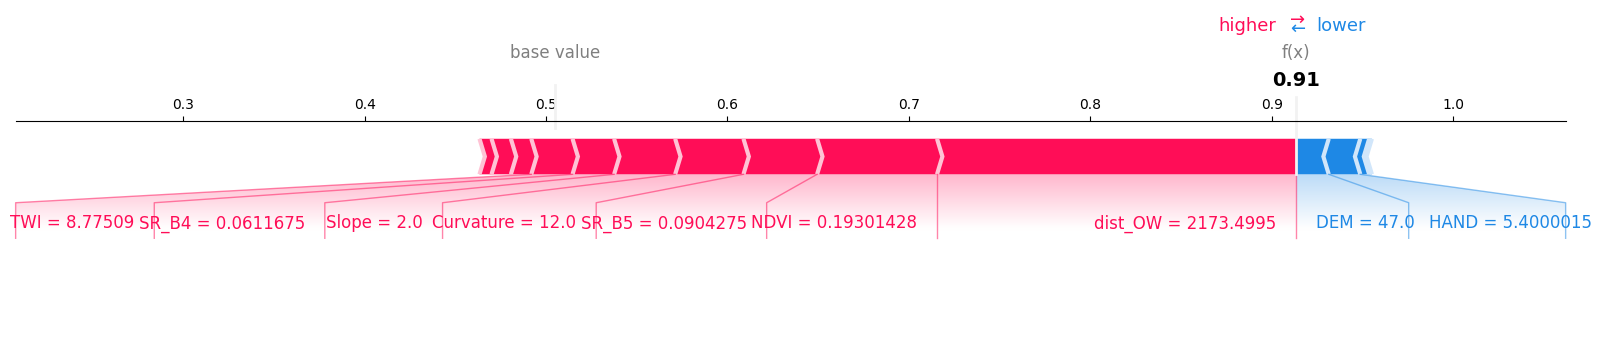

In [ ]:
# Elegir una observación (píxel) a explicar
row_id = 0 # Changed from 60 to 0 to be within valid index range
observation = X_train_df.iloc[[row_id]]

# Explicación local tipo SHAP para RF
pp_rf = exp_rf.predict_parts(
    observation,
    type="shap_wrapper",
    shap_explainer_type="TreeExplainer",
    check_additivity=False
)

# Gráfico de contribuciones SHAP para ese píxel
pp_rf.plot()

,variable,effect
0,DEM <= 37.00,0.090087
1,460.51 < dist_OW <= 754.48,-0.084560
2,1.20 < HAND <= 3.35,0.078391
3,SR_B5 > 0.21,-0.076336
4,SR_B6 > 0.16,-0.053325
5,TWI > 9.19,0.046218
6,NDVI <= 0.25,0.036234
7,Dist_Roads <= 0.00,-0.033469
8,2.00 < Slope <= 3.00,0.024426
9,SR_B3 > 0.08,-0.010631


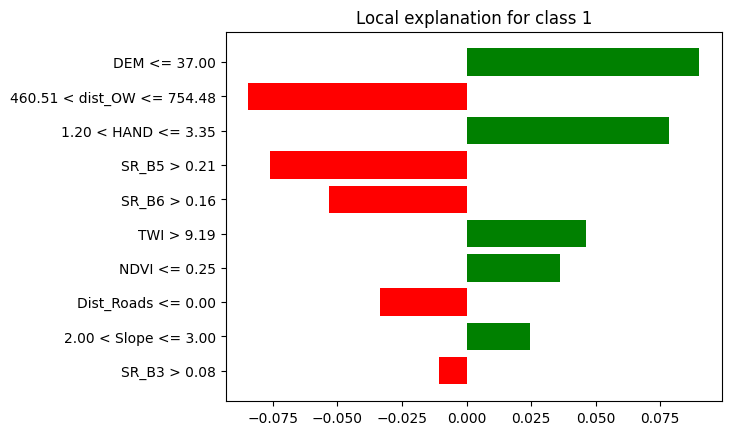

In [ ]:
# Volvemos a tomar una observación concreta
observation_to_predict = X_train_df.iloc[[50]]

# LIME usando DALEX (surrogate local)
lime_rf = exp_rf.predict_surrogate(observation_to_predict)

# Gráfico LIME para ese píxel
lime_rf.plot()

# Tabla de resultados LIME
lime_rf.result


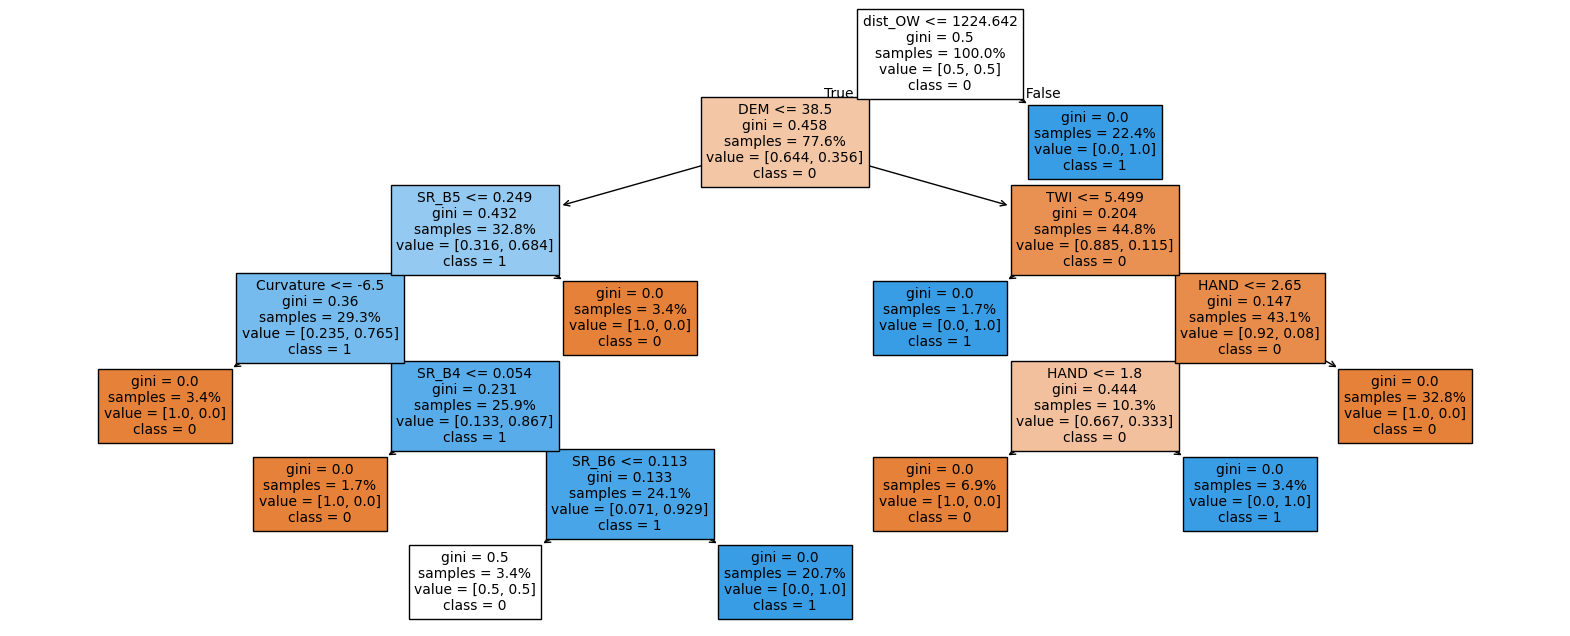

In [ ]:
# Surrogate global tipo árbol de decisión
surrogate_model_rf = exp_rf.model_surrogate(
    type="tree",
    max_depth=6,   # profundidad pequeña para que sea interpretable
    max_vars=10     # máximo de variables por nodo
)

surrogate_model_rf.performance   # qué tanto imita al RF

# Plot del árbol surrogate
surrogate_model_rf.plot(
    figsize=(20, 8),
    fontsize=10,
    filled=True
)


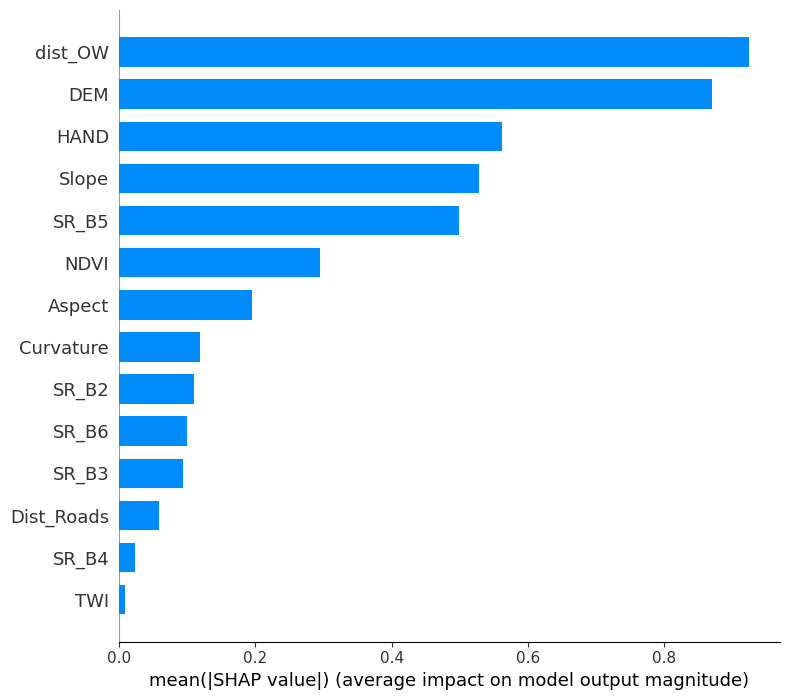

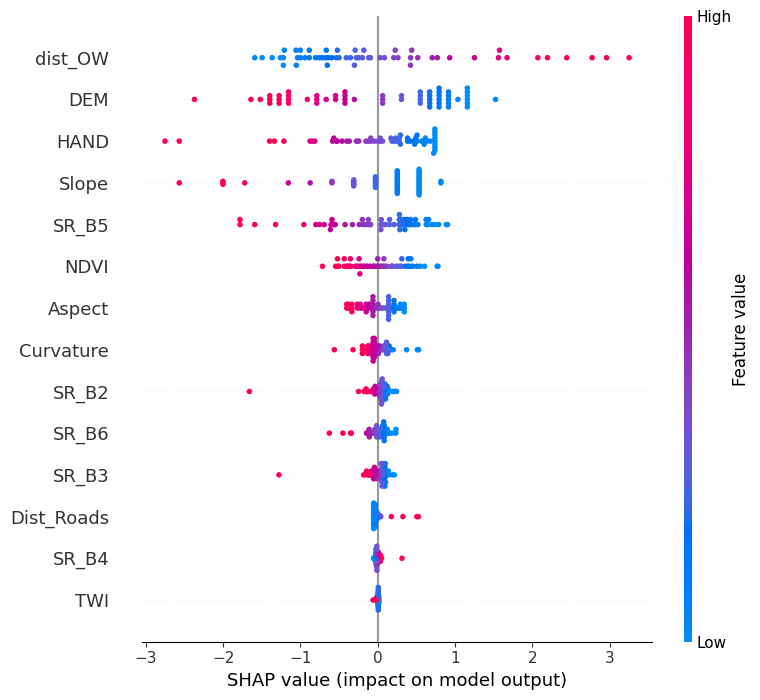

In [ ]:
# SHAP global para logit
mp_shap_logit = exp_logit.model_parts(
    type="shap_wrapper",
    shap_explainer_type="LinearExplainer"
)
mp_shap_logit.plot(plot_type='bar')
mp_shap_logit.plot()

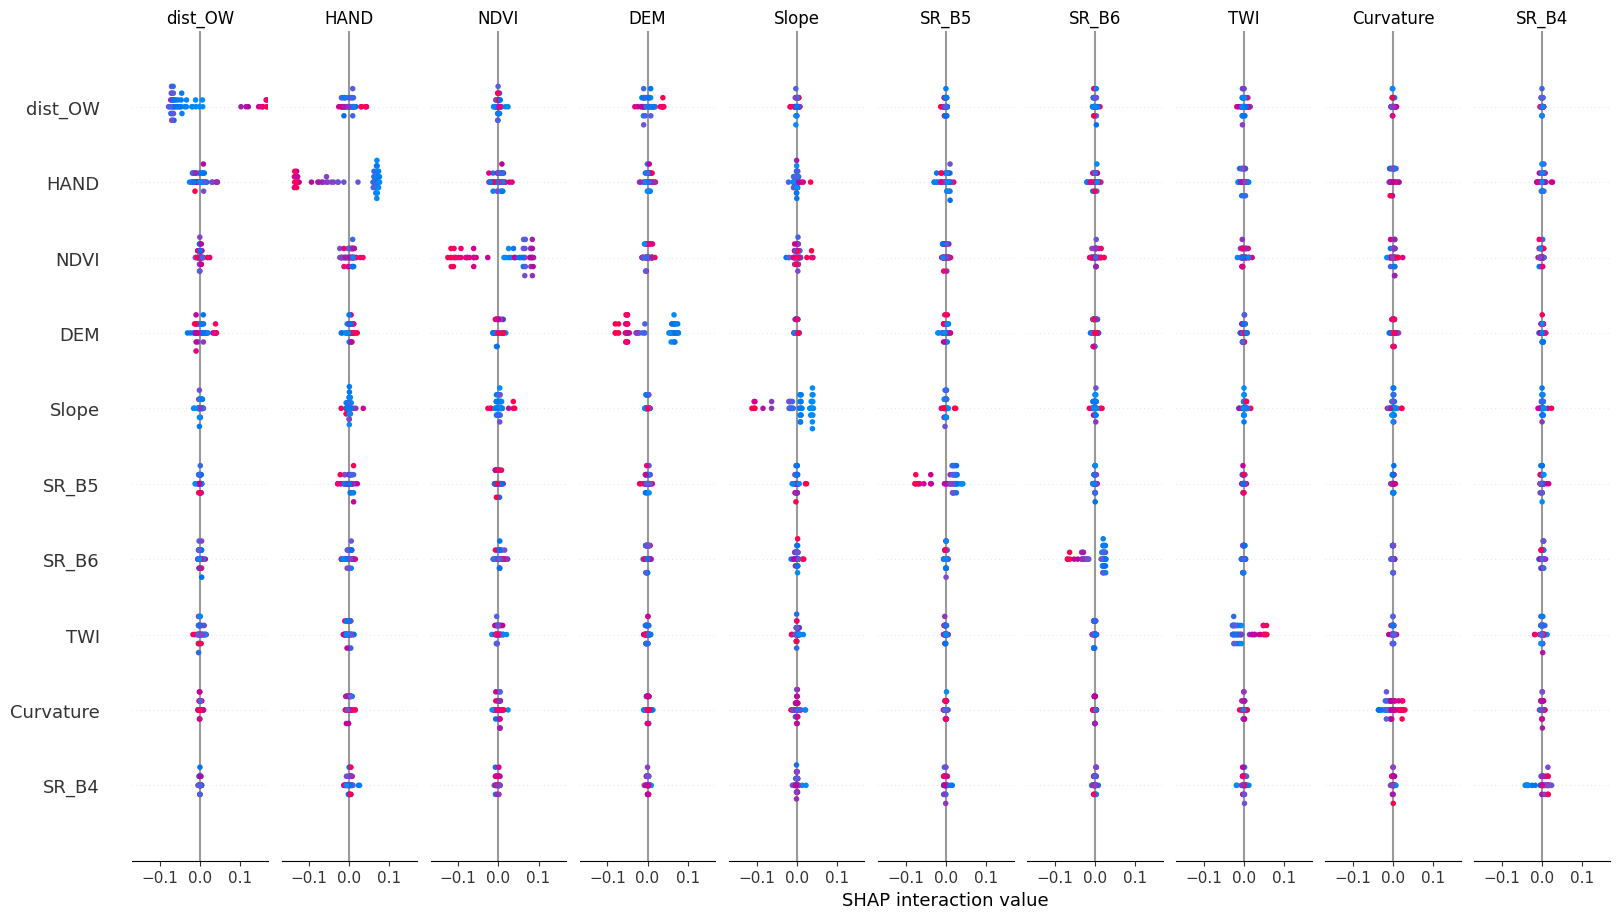

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train_df)

shap_inter = explainer.shap_interaction_values(X_train_df)

# The shap_inter array for a binary classifier in this context appears to be 4-dimensional,
# with shape (samples, feature_i, feature_j, class).
# We need to select the interaction values for a specific class, for example, class 1 (index 1).
shap.summary_plot(
    shap_inter[:, :, :, 1], # Select interaction values for class 1
    X_train_df,
    max_display=10
)